# 🧪 Python + NumPy + pandas Mini-Practical — **Solutions**

Dataset used: `practice_data.csv`

## 1) Bug hunt: function input / return mismatch

In [1]:
# Q1 — Part A (buggy by design, with explanation on the offending line)
def stringify_number(x):
    # returns a string version of the input number
    return x + "!"   # TypeError: can't add (concatenate) str to an int; x is numeric so this fails

n = 7
# out = stringify_number(n)  # <-- would error; commented to keep the cell runnable
# print(out)

In [2]:
# Q1 — Part B (corrected)
def stringify_number(x):
    return str(x) + "!"

n = 7
out = stringify_number(n)
print(out)  # expected: 7!

7!


## 2) NumPy: list math vs. array math

In [3]:
# Q2 — Part A (runs but wrong logic)
a = [1, 2, 3]
b = [10, 20, 30]

c = a + b   # This concatenates lists in Python → [1, 2, 3, 10, 20, 30], not elementwise addition
print(c)

[1, 2, 3, 10, 20, 30]


In [4]:
# Q2 — Part B (corrected with NumPy arrays)
import numpy as np

a = [1, 2, 3]
b = [10, 20, 30]

c = np.array(a) + np.array(b)
print(c)  # [11 22 33]

[11 22 33]


## 3) DataFrame subset by a logical condition (age ≥ 30)

In [ ]:
# Q3
import pandas as pd

df = pd.read_csv("/mnt/data/practice_data.csv")

df_age30 = df.query("age >= 30")
print(len(df_age30))  # number of rows satisfying the condition


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/practice_data.csv'

## 4) Write & apply a classification function (exam_score ≥ 80 → Pass)

In [6]:
# Q4
def grade_label(x):
    if x >= 80:
     return "Pass"
    else:
     return "Fail"

df["result"] = df["exam_score"].apply(grade_label)
df.head()

NameError: name 'df' is not defined

## 5) Random assignment into two groups using a uniform random variable

In [9]:
# Q5 (using .query)
import numpy as np

# Create random uniform variable between 0 and 1
num_rows, num_cols = df.shape
group_no = np.random.choice(["A", "B", "C"], size = num_rows)
df["GroupID"] = group_no


# Use query to split the DataFrame into two groups
grp_A = df.query("GroupID = 'A'")
grp_B = df.query("GroupID = 'B'")

# Check group sizes
len(grp_A), len(grp_B)

NameError: name 'df' is not defined

## 6) Side-by-side scatter plots for the two groups (age vs exam_score)

NameError: name 'grp_A' is not defined

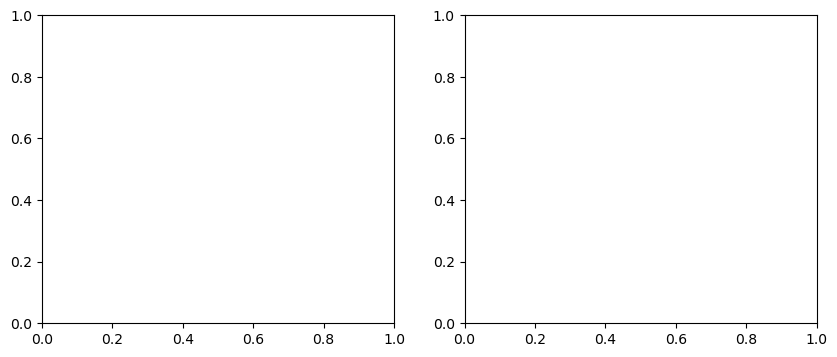

In [ ]:
# Q6
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(grp_A["age"], grp_A["exam_score"])
axes[0].set_title("Group A (random_var < 0.5)")
axes[0].set_xlabel("age")
axes[0].set_ylabel("exam_score")

axes[1].scatter(grp_B["age"], grp_B["exam_score"])
axes[1].set_title("Group B (random_var >= 0.5)")
axes[1].set_xlabel("age")
axes[1].set_ylabel("exam_score")

plt.tight_layout()
plt.show()